In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(asctime)s - %(message)s')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import re

from evaluate import load

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from IPython.display import clear_output

use_vad = True
use_excl_dz = True
narr_cosine_sim_lim = 0.14
diag_cosine_sim_lim = 0.3

whisper_model = 'turbo'
silero_threshold = 0.5

whisper_config = {
    'beam_size': 7,
    'no_speech_threshold': 0.1,
    'condition_on_previous_text': True
}

os.chdir('..') # Override jupyter's working directory back to project root
import audiodescription_abusedetection.data_extraction as da
from audiodescription_abusedetection import stt, utils, plotting

diarization_model = stt.pyannote_model_name
embedding_model = "pyannote/embedding"

import warnings
warnings.filterwarnings("ignore")

# logging.getLogger("speechbrain").setLevel(logging.WARNING)
logging.getLogger("pyannote").setLevel(logging.WARNING)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)
logging.getLogger('pytorch').setLevel(logging.ERROR)


# TODO: Create list of abandoned films and just delete to save space
# TODO: Create ground truth for Substance 

/home/raine-bianchini/Documents/projects/honours/audiodescription-abusedetection/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
films_list_df = da.get_or_create_subtitles_df()

In [3]:
credits_df = da.get_credits_timestamps()

In [4]:
config_list = []
for silero_threshold in [0.5]: # (0.4, 0.45, 0.5):
    for whisper_model in ['turbo']: # , 'large'
        for cosine_sim_lim in [0.2, 0.3, 0.4, 0.5, 0.8]: # np.arange(0.4, 1.2, 0.2): # 0.15, 0.2, 
            for beam_size in [7]:
                for speech_cond in [True]:
                    for no_speech_threshold in [0.1]: # , 0.2
                        for min_seg_sec in [0]: #np.arange(0, 0.6, 0.1):
                            config = {
                                'use_vad': use_vad,
                                'silero_threshold': silero_threshold,
                                'whisper_model': whisper_model,
                                'cosine_sim_lim': cosine_sim_lim,
                                'beam_size': beam_size,
                                'no_speech_threshold': no_speech_threshold,
                                'condition_on_previous_text': speech_cond,
                                'min_seg_sec': min_seg_sec
                            }
                            
                            config_list.append(config)

In [5]:
man_transcripts = [x for x in os.listdir(da.manual_transcript_dir) if x.endswith('.txt')]
movies = [utils.remove_ext(x) for x in man_transcripts]

In [6]:
for movie_name in movies:
    mp3_filename = f'{movie_name}.mp3'

    vad_df_path = os.path.join(da.voice_activity_dir, f'{movie_name}-vad.parquet')
    seg_df_path = os.path.join(da.diarization_dir, f'{movie_name}-diarization.parquet')
    curr_transcript_fp = os.path.join(da.transcript_dir, da.transcript_df_fp.format(movie_name=movie_name))
    wav_filepath = os.path.join(da.trans_mp3_dir, f'{movie_name}_speech_only.wav')

    # Perform initial calculations which aren't impacted by config parameter sweeps
    # stt.apply_silero_vad_to_wav(mp3_filename, wav_filepath, vad_df_path, silero_threshold=silero_threshold, credits_df=credits_df)
    # stt.apply_diarization(movie_name, wav_filepath, diarization_model, seg_df_path, vad_df_path, use_excl_dz, device)
    # stt.add_pyannote_cosine_sim(seg_df_path, wav_filepath, min_seg_sec=0, device=device)

    # Narrator Cosine sim limit is set to 0 for exploration, so deletion/retranscription needs to occur if movies have already been transcribed
    stt.transcribe_segments(curr_transcript_fp, seg_df_path, wav_filepath, whisper_model, whisper_config, 0, device)

Transcribing segments:   0%|          | 0/322 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
cer, wer = load('cer'), load('wer')
results = []
word_counts = []

for movie_name in movies:
    curr_transcript_fp = os.path.join(da.transcript_dir, da.transcript_df_fp.format(movie_name=movie_name))
    trans_df = pd.read_parquet(curr_transcript_fp)
    trans_df = trans_df[trans_df['text'].ne(' Thank you.')]

    with open(os.path.join(da.manual_transcript_dir, f'{movie_name}.txt')) as fileobj:
        raw_txt = fileobj.read()
    ref_txt = re.sub('[\.,"\?!:]', '', raw_txt).lower().replace('-', ' ').replace('\n', ' ')
    word_counts.append(len(ref_txt.split(' ')))

    for lim in np.arange(0, 1, 0.01):
        curr_trans_df = trans_df[trans_df.cosine_sim.gt(lim)].copy()
        trans_txt = ''.join(curr_trans_df.text.str.replace('[\.,"\?!]', '', regex=True)).lower().replace('-', ' ')

        wer_score = wer.compute(predictions=[trans_txt], references=[ref_txt])
        cer_score = cer.compute(predictions=[trans_txt], references=[ref_txt])
        results.append({'lim': lim, 'cer': cer_score, 'wer': wer_score, 'movie': movie_name})

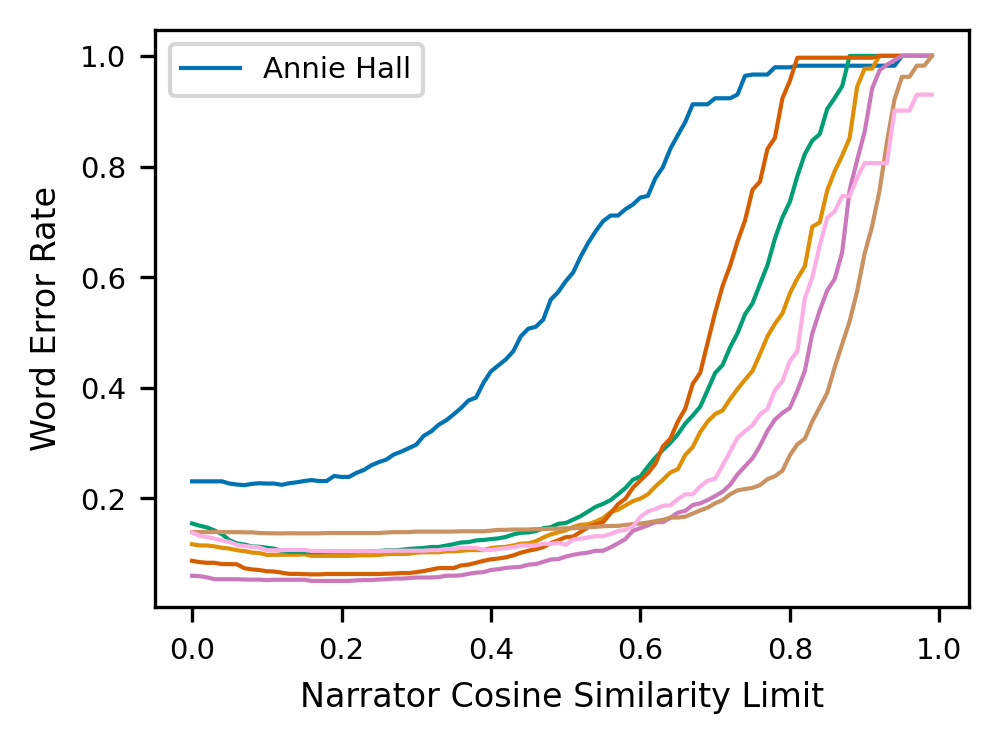

In [ ]:
results_df = pd.DataFrame(results).sort_values(['movie', 'lim'])

sns.lineplot(results_df, x='lim', y='wer', hue='movie')
plt.ylabel('Word Error Rate')
plt.xlabel('Narrator Cosine Similarity Limit')
plt.legend(['Annie Hall'])
plt.savefig(os.path.join(plotting.output_dir, 'WER vs Cosine Similarity Limit.png'), bbox_inches='tight')

In [ ]:
weights = np.array(word_counts) / sum(word_counts)
avg_wer = (results_df[results_df.lim.eq(narr_cosine_sim_lim)]['wer'].values * weights).sum().round(4)
print(f'Average WER of Narration: {avg_wer}')

Average WER of Narration: 0.1266


In [ ]:
results = []

for ii, config in enumerate(config_list):
    logging.info(f'NEW CONFIG RUN: \t{ii} / {len(config_list)}')
    for movie_name in movies:
        # da.wipe_movie_files(movie_name)

        vad_df_path = os.path.join(da.voice_activity_dir, f'{movie_name}-vad.parquet')
        seg_df_path = os.path.join(da.diarization_dir, f'{movie_name}-diarization.parquet')
        curr_transcript_fp = os.path.join(da.transcript_dir, da.transcript_df_fp.format(movie_name=movie_name))
        wav_filepath = os.path.join(da.trans_mp3_dir, f'{movie_name}_speech_only.wav')
    
        use_vad = config['use_vad']
        silero_threshold = config['silero_threshold']
        whisper_model = config['whisper_model']
        cosine_sim_lim = config['cosine_sim_lim']
        whisper_config['beam_size'] = config['beam_size']
        whisper_config['no_speech_threshold'] = config['no_speech_threshold']
        whisper_config['condition_on_previous_text'] = config['condition_on_previous_text']
        min_seg_sec = config['min_seg_sec']
        
        # stt.apply_pyannote_vad_to_wav(mp3_filename, wav_filepath, vad_df_path, device, credits_df)
        # stt.apply_silero_vad_to_wav(mp3_filename, wav_filepath, vad_df_path, silero_threshold=silero_threshold, credits_df=credits_df)
        # stt.apply_diarization(movie_name, wav_filepath, diarization_model, seg_df_path, device)
        # stt.add_pyannote_cosine_sim(seg_df_path, wav_filepath, min_seg_sec=min_seg_sec, device=device)
        stt.transcribe_segments(curr_transcript_fp, seg_df_path, wav_filepath, whisper_model, whisper_config, narr_cosine_sim_lim, device)
        
        wer = da.calc_wer(movie_name)
        results.append({'wer': wer})
        print(results[-1])

INFO - 2025-07-15 18:38:26,219 - NEW CONFIG RUN: 	0 / 5


RuntimeError: Failed to load audio: ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --e

In [ ]:
movie_name = 'Earth to Echo'
trans_df = pd.read_parquet(os.path.join(da.transcript_dir, da.transcript_df_fp.format(movie_name=movie_name)))
trans_df = trans_df[trans_df['text'].ne(' Thank you.')]
trans_txt = ''.join(trans_df.text.str.replace('[\.,"\?!]', '', regex=True)).lower().replace('-', ' ')

with open(os.path.join(da.transcript_dir, 'manual', f'{movie_name}.txt')) as fileobj:
    raw_txt = fileobj.read()
ref_txt = re.sub('[\.,"\?!:]', '', raw_txt).lower().replace('-', ' ').replace('\n', ' ')

stt.visualise_wer_differences(trans_txt, ref_txt)
wer.compute(predictions=[trans_txt], references=[ref_txt])